# 기본 코드

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (4,067 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121752 files and dire

In [1]:
import pandas as pd
import numpy as np

# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

import seaborn as sns

In [2]:
plt.rc('font', family='NanumBarunGothic')

In [3]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 기존 등급 고객 분석

In [5]:
mem = pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/마켓프로젝트/마켓 CSV파일모음/finmem.csv")
mem

,회원번호,조합원상태,시,주소,성별,연령,연령대,배송서비스신청여부,모바일알람여부,Gold_member
0,1000012800,정상회원,용인,수지구-풍덕천동,여,58.0,50대,미신청,.,normal
1,1000103744,정상회원,용인,처인구-고림동,여,34.0,30대,미신청,.,normal
2,1000122304,정상회원,광주,광주-기타,여,38.0,30대,미신청,.,normal
3,1000163136,정상회원,용인,수지구-동천동,여,73.0,70대,미신청,.,normal
4,1000281920,정상회원,용인,수지구-풍덕천동,여,42.0,40대,신청,.,normal
...,...,...,...,...,...,...,...,...,...,...
11550,999682432,탈퇴,용인,수지구-동천동,여,47.0,40대,미신청,.,normal
11551,999721408,정상회원,용인,수지구-동천동,여,43.0,40대,미신청,.,normal
11552,999738112,정상회원,용인,수지구-성복동,여,67.0,60대,미신청,.,normal
11553,999754816,정상회원,용인,수지구-상현동,여,44.0,40대,신청,.,normal


(array([11350.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,   205.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

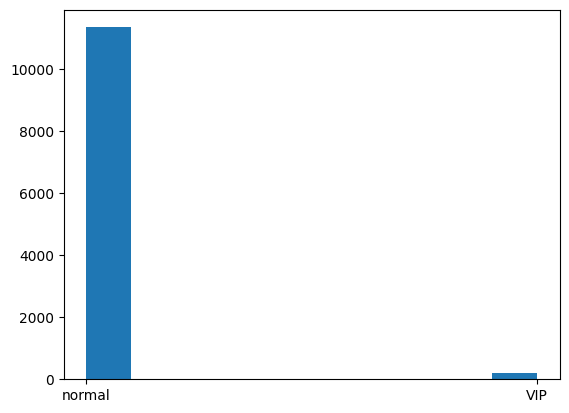

In [ ]:
plt.hist(mem['Gold_member'])

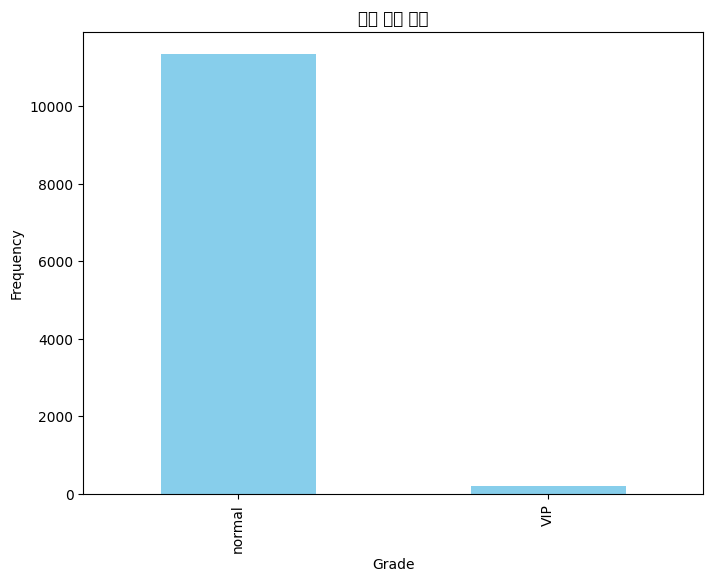

In [ ]:
grade_counts = mem['Gold_member'].value_counts()

# 막대 그래프 생성
plt.figure(figsize=(8, 6))
grade_counts.plot(kind='bar', color='skyblue')

# 그래프 제목과 축 레이블 추가
plt.title('기존 등급 분포')
plt.xlabel('Grade')
plt.ylabel('Frequency')

# 그래프 표시
plt.show()


In [ ]:
mem['Gold_member'].value_counts()

normal    11350
VIP         205
Name: Gold_member, dtype: int64

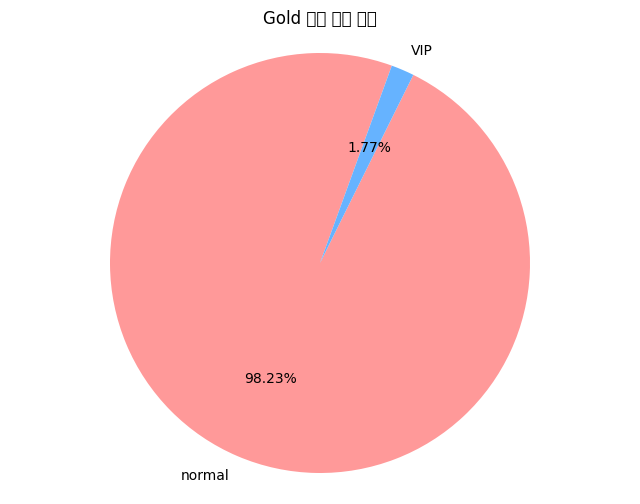

In [ ]:
# 'Gold_member' 열의 값에 대한 개수 세기
gold_member_counts = mem['Gold_member'].value_counts()

# 파이 차트 그리기
plt.figure(figsize=(8, 6))
plt.pie(gold_member_counts, labels=gold_member_counts.index, colors=['#ff9999', '#66b3ff'], autopct='%1.2f%%', startangle=70)
plt.title('Gold 회원 유형 비율')
plt.axis('equal')  # 원형으로 조정
plt.show()

In [ ]:
vip = mem[mem['Gold_member'] == 'VIP']
vip

,회원번호,조합원상태,시,주소,성별,연령,연령대,배송서비스신청여부,모바일알람여부,Gold_member
235,1019647424,정상회원,용인,수지구-동천동,여,54.0,50대,미신청,수신,VIP
381,1035466112,정상회원,용인,수지구-풍덕천동,여,47.0,40대,미신청,수신,VIP
424,1039972480,정상회원,용인,수지구-상현동,여,42.0,40대,미신청,수신,VIP
483,104683968,정상회원,용인,수지구-풍덕천동,여,72.0,70대,미신청,.,VIP
525,1051939968,정상회원,용인,수지구-상현동,여,46.0,40대,미신청,수신,VIP
...,...,...,...,...,...,...,...,...,...,...
11444,980225984,정상회원,기타,기타-기타,여,43.0,40대,미신청,수신,VIP
11490,993938112,정상회원,용인,수지구-신봉동,여,47.0,40대,미신청,수신,VIP
11492,994348288,정상회원,용인,수지구-풍덕천동,여,32.0,30대,미신청,수신,VIP
11512,99763712,정상회원,용인,수지구-신봉동,여,48.0,40대,미신청,수신,VIP


In [ ]:
vip['연령대'].value_counts()

40대       79
50대       65
60대       30
70대       13
30대       13
80대 이상     5
Name: 연령대, dtype: int64

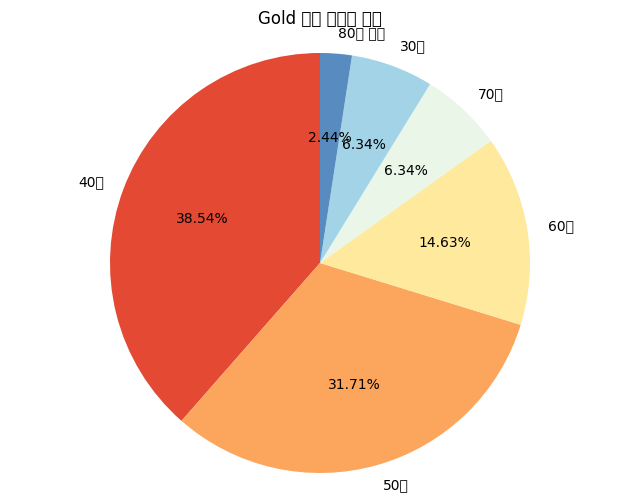

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# '연령대' 열의 값에 대한 개수 세기
age = vip['연령대'].value_counts()

# 색상 그라데이션 적용을 위한 색상 팔레트 선택
colors = sns.color_palette("RdYlBu", len(age))

# 파이 차트 그리기
plt.figure(figsize=(8, 6))
plt.pie(age, labels=age.index, colors=colors, autopct='%1.2f%%', startangle=90)
plt.title('Gold 회원 연령대 비율')
plt.axis('equal')  # 원형으로 조정
plt.show()


In [ ]:
vip['시'].value_counts()

용인    195
성남      6
기타      3
수원      1
Name: 시, dtype: int64

In [ ]:
vip['배송서비스신청여부'].value_counts()

미신청    205
Name: 배송서비스신청여부, dtype: int64

충격 vip 는 다 배송서비스 신청 안함

In [ ]:
vip['모바일알람여부'].value_counts()

수신    157
.      48
Name: 모바일알람여부, dtype: int64

# vip 고객 소비 패턴 알아보기

In [7]:
market = pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/마켓프로젝트/마켓 CSV파일모음/전체매장데이터.csv")
market

,공급일자,회원번호,조합원상태,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,구매시각,반품일자,구매월,구매일,구매시간대,반품소요기간
0,2023-01-06,220954944,정상회원,반찬,두부/유부,두부,두부(1모:420g),1.0,3829,매장A,10:32:00,NaN,1,6,10,0
1,2023-01-06,89023040,정상회원,채소,열매채소,단호박/손질,단호박(깍뚝썰기/300g),1.0,4977,매장A,10:41:00,NaN,1,6,10,0
2,2023-01-06,354941440,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,11:00:00,NaN,1,6,11,0
3,2023-01-06,786634048,탈퇴,반찬,어묵/묵,묵,도토리묵(420g:1모),1.0,7083,매장A,11:28:00,NaN,1,6,11,0
4,2023-01-06,438543104,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,11:59:00,NaN,1,6,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294640,2023-11-04,560448896,정상회원,주곡,멥쌀,멥쌀,백미/유(2kg),1.0,15315,매장D,13:16:00,NaN,11,4,13,0
294641,2023-11-04,68976384,정상회원,채소,잎/줄기채소,시금치,시금치(300g),2.0,6892,매장D,11:08:00,NaN,11,4,11,0
294642,2023-11-04,1519813440,정상회원,반찬,밑반찬,김가공,구운자른김(15g*3봉),1.0,7466,매장D,14:27:00,NaN,11,4,14,0
294643,2023-11-04,654809792,정상회원,반찬,두부/유부,두부,두부(1모:420g),1.0,3733,매장D,16:02:00,NaN,11,4,16,0


In [ ]:
market[market['물품대분류'] == '건강']

,공급일자,회원번호,조합원상태,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,구매시각,반품일자,구매월,구매일,구매시간대,반품소요기간
8,2023-01-06,967046528,정상회원,건강,홍삼/녹용,홍삼,홍삼액(6년근/60봉),1.0,229730,매장A,12:45:00,NaN,1,6,12,0
36,2023-01-06,762513472,정상회원,건강,건강일반,추출/농축액,양배추브로콜리액(100ml*30봉),1.0,42117,매장A,12:52:00,NaN,1,6,12,0
67,2023-01-06,312678464,정상회원,건강,건강일반,추출/농축액,떠먹는배도라지청(230g),1.0,38288,매장A,14:37:00,NaN,1,6,14,0
297,2023-01-07,840584256,정상회원,건강,건강일반,추출/농축액,쌍화차(70ml),3.0,14932,매장A,19:24:00,NaN,1,7,19,0
303,2023-01-07,1004836544,정상회원,건강,건강일반,분말/환,홍도라지가루(2g*30봉),0.2,5743,매장A,12:04:00,NaN,1,7,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294097,2023-11-01,517528896,정상회원,건강,건강일반,추출/농축액,채소액(유기/150ml*30봉),0.2,10146,매장D,15:10:00,NaN,11,1,15,0
294149,2023-11-02,389065856,정상회원,건강,건강일반,추출/농축액,쌍화차(70ml*10봉),1.0,49775,매장D,13:22:00,NaN,11,2,13,0
294546,2023-11-04,336028800,정상회원,건강,건강일반,추출/농축액,생칡즙(140ml*10봉),1.0,19144,매장D,17:48:00,NaN,11,4,17,0
294583,2023-11-04,1472355520,정상회원,건강,건강일반,분말/환,홍도라지가루(2g*30봉),0.1,2872,매장D,12:18:00,NaN,11,4,12,0


In [ ]:
market[(market['구매매장'] == '매장A') & (market['구매시간대'] == 14)]

,공급일자,회원번호,조합원상태,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,구매시각,반품일자,구매월,구매일,구매시간대,반품소요기간
11,2023-01-06,269949632,정상회원,간식,잼/병조림/기타,잼,딸기잼(480g),1.0,12922,매장A,14:01:00,NaN,1,6,14,0
12,2023-01-06,727869376,정상회원,반찬,밑반찬,조림,우엉조림(김밥용/150g),1.0,7658,매장A,14:19:00,NaN,1,6,14,0
39,2023-01-06,982122816,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,14:16:00,NaN,1,6,14,0
40,2023-01-06,1500227072,정상회원,채소,버섯,양송이버섯,갈색양송이버섯(140g),1.0,5552,매장A,14:30:00,NaN,1,6,14,0
41,2023-01-06,1042767616,정상회원,수산,건어물,황태류,황태채(200g),1.0,21824,매장A,14:44:00,NaN,1,6,14,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52521,2023-11-04,1202004992,정상회원,과실,과일,귤(조생),귤/유(1.5kg),1.0,10912,매장A,14:40:00,NaN,11,4,14,0
52554,2023-11-04,469100288,정상회원,간식,빵,"식빵, 식사대용",샌드위치식빵(270g)/매장,1.0,5169,매장A,14:19:00,NaN,11,4,14,0
52558,2023-11-04,1040081984,정상회원,채소,열매채소,오이,오이(3개),1.0,4020,매장A,14:38:00,NaN,11,4,14,0
52561,2023-11-04,1171624128,정상회원,간식,과자,스낵,도깨비방망이과자(80g),1.0,4212,매장A,14:47:00,NaN,11,4,14,0


In [ ]:
market[(market['구매매장'] == '매장A') & (market['구매시간대'] == 15)]

,공급일자,회원번호,조합원상태,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,구매시각,반품일자,구매월,구매일,구매시간대,반품소요기간
13,2023-01-06,777463552,정상회원,반찬,두부/유부,두부,연두부(100g),2.0,1532,매장A,15:00:00,NaN,1,6,15,0
14,2023-01-06,393343936,정상회원,채소,잎/줄기채소,양상추,양상추(300g:1통),1.0,4786,매장A,15:11:00,NaN,1,6,15,0
15,2023-01-06,138689600,정상회원,간식,빵,단과자빵,카스텔라(소:100g)/매장,2.0,4977,매장A,15:17:00,NaN,1,6,15,0
16,2023-01-06,922081216,정상회원,양념/가루,소스/기타양념,기타양념,유기쌀올리고당(440g),2.0,22207,매장A,15:24:00,NaN,1,6,15,0
17,2023-01-06,1040210048,정상회원,반찬,두부/유부,두부,찌개용두부(420g),3.0,10912,매장A,15:39:00,NaN,1,6,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52542,2023-11-04,630798720,정상회원,수산,건어물,기타건어류,남해바다 아귀포(120g),1.0,17230,매장A,15:01:00,NaN,11,4,15,0
52543,2023-11-04,876408768,정상회원,간식,밀가공,피자/핫도그,통밀또띠아(40g*10장),1.0,9955,매장A,15:06:00,NaN,11,4,15,0
52549,2023-11-04,1009040384,정상회원,음료,음료,과즙,포도즙(팩:120ml*20봉),1.0,60878,매장A,15:15:00,NaN,11,4,15,0
52550,2023-11-04,419628608,정상회원,양념/가루,가루,고춧가루,고춧가루/유(2kg/양념용),-2.0,-356081,매장A,15:48:00,2023-11-05,11,4,15,1


In [ ]:
market[(market['구매매장'] == '매장A') & (market['구매시간대'] == 17)]

,공급일자,회원번호,조합원상태,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,구매시각,반품일자,구매월,구매일,구매시간대,반품소요기간
23,2023-01-06,644189760,정상회원,음료,음료,푸딩,과일푸딩(포도:110g),4.0,10721,매장A,17:17:00,NaN,1,6,17,0
24,2023-01-06,749244928,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,17:24:00,NaN,1,6,17,0
49,2023-01-06,437884224,정상회원,축산물,유제품,아이스크림,유기농요거트딸기아이스크림(100ml),1.0,2680,매장A,17:10:00,NaN,1,6,17,0
50,2023-01-06,644189760,정상회원,축산물,유제품,아이스크림,유기농아이스크림(딸기맛),1.0,17038,매장A,17:17:00,NaN,1,6,17,0
51,2023-01-06,766685760,정상회원,채소,잎/줄기채소,어린잎채소,어린잎채소(100g),1.0,5552,매장A,17:51:00,NaN,1,6,17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52476,2023-11-04,539986496,정상회원,간식,식사대용,식사대용/기타,곤드레나물밥(624g),2.0,26802,매장A,17:22:00,NaN,11,4,17,0
52493,2023-11-04,1505130624,정상회원,반찬,두부/유부,두부,찌개용두부(420g),1.0,3542,매장A,17:33:00,NaN,11,4,17,0
52515,2023-11-04,478385856,정상회원,간식,과자,스낵,우리밀유정란전병(150g),1.0,4212,매장A,17:46:00,NaN,11,4,17,0
52534,2023-11-04,1505130624,정상회원,반찬,밑반찬,김가공,구운자른김(15g*3봉),1.0,7466,매장A,17:33:00,NaN,11,4,17,0


In [ ]:
merged_vip = pd.merge(vip, market, on=['회원번호', '조합원상태'])
merged_vip

,회원번호,조합원상태,시,주소,성별,연령,연령대,배송서비스신청여부,모바일알람여부,Gold_member,...,물품명,구매수량,구매금액,구매매장,구매시각,반품일자,구매월,구매일,구매시간대,반품소요기간
0,1019647424,정상회원,용인,수지구-동천동,여,54.0,50대,미신청,수신,VIP,...,시금치(300g),1.0,4403,매장A,13:06:00,NaN,1,6,13,0
1,1019647424,정상회원,용인,수지구-동천동,여,54.0,50대,미신청,수신,VIP,...,플레인요구르트(범산/450ml),1.0,7849,매장A,13:06:00,NaN,1,6,13,0
2,1019647424,정상회원,용인,수지구-동천동,여,54.0,50대,미신청,수신,VIP,...,한재미나리(200g),1.0,6700,매장A,13:06:00,NaN,1,6,13,0
3,1019647424,정상회원,용인,수지구-동천동,여,54.0,50대,미신청,수신,VIP,...,창난젓(250g),1.0,13401,매장A,13:06:00,NaN,1,6,13,0
4,1019647424,정상회원,용인,수지구-동천동,여,54.0,50대,미신청,수신,VIP,...,오징어채(200g),1.0,17038,매장A,19:22:00,NaN,1,7,19,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43109,999227712,정상회원,용인,수지구-상현동,여,40.0,40대,미신청,수신,VIP,...,수피아 쌀겨 마스크팩(5+1),2.0,21824,매장B,16:27:00,NaN,11,2,16,0
43110,999227712,정상회원,용인,수지구-상현동,여,40.0,40대,미신청,수신,VIP,...,사과/무(1.5kg),-1.0,-18187,매장B,14:26:00,2023-11-05,11,4,14,1
43111,999227712,정상회원,용인,수지구-상현동,여,40.0,40대,미신청,수신,VIP,...,연근채(300g),-1.0,-7275,매장B,14:26:00,2023-11-05,11,4,14,1
43112,999227712,정상회원,용인,수지구-상현동,여,40.0,40대,미신청,수신,VIP,...,가자미(2~4마리/300g),-1.0,-14358,매장B,14:26:00,2023-11-06,11,4,14,2


In [ ]:
merged_vip['구매매장'].value_counts()

매장C    24564
매장D     7231
매장B     6276
매장A     5043
Name: 구매매장, dtype: int64

기존 vip 고객들은 c매장을 많이 이용함

In [ ]:
merged_vip['반품일자'].count()

981

In [ ]:
merged_vip['물품대분류'].value_counts()

채소       12681
축산물       7409
간식        6813
반찬        4415
수산        2755
과실        1749
음료        1690
양념/가루     1656
생활용품      1629
서류         669
주곡         603
잡곡         488
건강         441
주류          75
기타          41
Name: 물품대분류, dtype: int64

vip 고객별 총구매금액, 가장 많이 구매한 대,중,소 분류, 평균 구매금액과 최고구매금액을 저장한 데이터프레임 저장

In [ ]:
# 1. 고객별로 구매금액을 합산하여 총구매금액 계산
total_purchase_amount = merged_vip.groupby('회원번호')['구매금액'].sum()

# 2. 고객별로 구매한 물품들의 대분류, 중분류, 소분류를 기록
customer_purchase_categories = merged_vip.groupby('회원번호').agg({
    '물품대분류': lambda x: x.mode()[0],  # 가장 많이 구매한 대분류
    '물품중분류': lambda x: x.mode()[0],  # 가장 많이 구매한 중분류
    '물품소분류': lambda x: x.mode()[0]   # 가장 많이 구매한 소분류
})

# 3. 각 고객의 구매 내역을 요약하여 1인당 평균구매금액과 최고구매금액 계산
customer_purchase_summary = merged_vip.groupby('회원번호').agg({
    '구매금액': ['sum','mean', 'max']  # 1인당 평균구매금액과 최고구매금액
})
customer_purchase_summary.columns = ['총구매금액','평균구매금액', '최고구매금액']

#고객 연령대
agegroup = merged_vip.groupby('회원번호')['연령대'].first()

# 고객별 총구매금액, 가장 많이 구매한 물품 대분류, 중분류, 소분류 정보를 합치기
vip_info = pd.concat([total_purchase_amount, customer_purchase_categories, customer_purchase_summary,agegroup], axis=1)

# 결과 출력
vip_info


,구매금액,물품대분류,물품중분류,물품소분류,총구매금액,평균구매금액,최고구매금액,연령대
회원번호,,,,,,,,
20588608,2774143,간식,소,한우,2774143,12552.683258,64324,50대
22270144,2104267,축산물,유제품,우유/산양유,2104267,10736.056122,302477,50대
38588096,3011821,채소,과일,우유/산양유,3011821,13943.615741,321622,50대
38959296,2313909,채소,잎/줄기채소,두부,2313909,8147.566901,37882,50대
48638336,4416654,채소,잎/줄기채소,우유/산양유,4416654,11069.308271,146261,60대
...,...,...,...,...,...,...,...,...
1479170752,2093036,채소,열매채소,오이,2093036,14636.615385,166554,70대
1540686016,2699561,채소,과자,스낵,2699561,11788.475983,308221,60대
1547417728,2240724,채소,양념채소,돼지(중량),2240724,8891.761905,55901,60대


In [ ]:
vip_info['물품대분류'].value_counts()

채소     149
간식      32
축산물     20
반찬       4
Name: 물품대분류, dtype: int64

(array([50., 65., 43., 26.,  6., 12.,  1.,  0.,  0.,  2.]),
 array([ 443091. , 1354779.9, 2266468.8, 3178157.7, 4089846.6, 5001535.5,
        5913224.4, 6824913.3, 7736602.2, 8648291.1, 9559980. ]),
 <BarContainer object of 10 artists>)

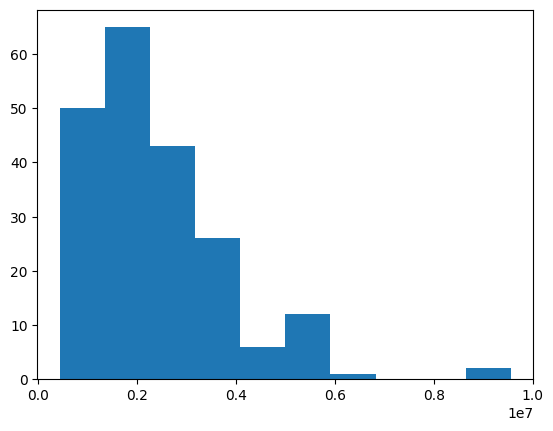

In [ ]:
plt.hist(vip_info['구매금액'])

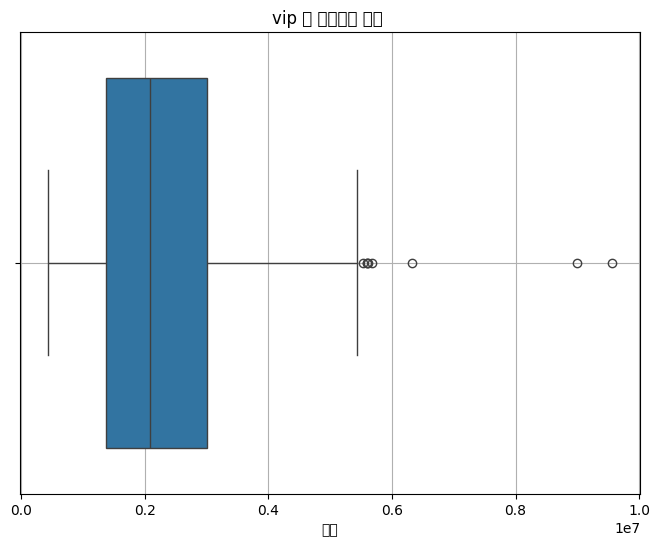

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=vip_info['구매금액'])
plt.title('vip 총 구매금액 분포 ')
plt.xlabel('금액')
plt.grid(True)
plt.show()

(array([19., 54., 60., 41., 11., 12.,  4.,  2.,  0.,  2.]),
 array([ 5687.34306569,  7584.55652032,  9481.76997494, 11378.98342957,
        13276.19688419, 15173.41033882, 17070.62379344, 18967.83724807,
        20865.05070269, 22762.26415732, 24659.47761194]),
 <BarContainer object of 10 artists>)

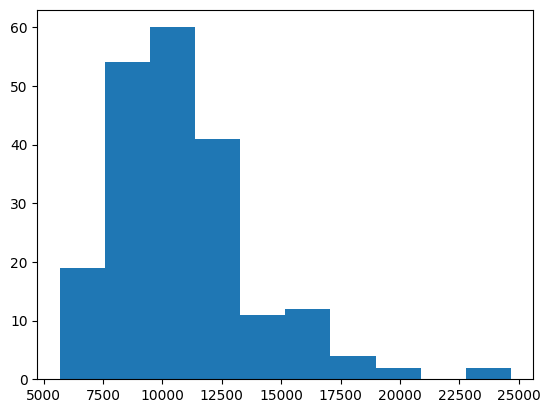

In [ ]:
plt.hist(vip_info['평균구매금액'])

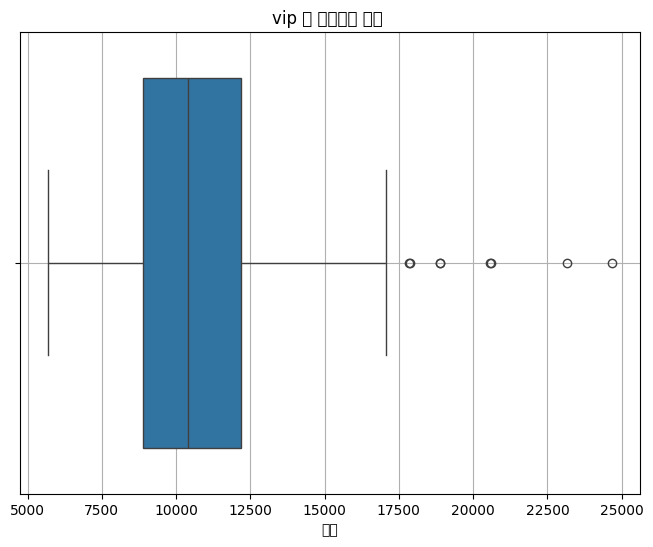

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=vip_info['평균구매금액'])
plt.title('vip 총 구매금액 분포 ')
plt.xlabel('금액')
plt.grid(True)
plt.show()

(array([19., 54., 60., 41., 11., 12.,  4.,  2.,  0.,  2.]),
 array([ 5687.34306569,  7584.55652032,  9481.76997494, 11378.98342957,
        13276.19688419, 15173.41033882, 17070.62379344, 18967.83724807,
        20865.05070269, 22762.26415732, 24659.47761194]),
 <BarContainer object of 10 artists>)

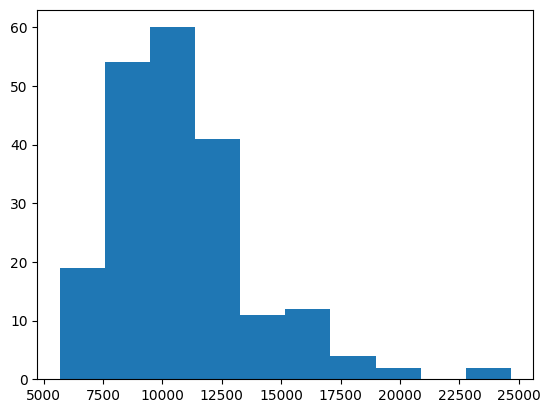

In [ ]:
plt.hist(vip_info['평균구매금액'])

# Normal 고객 소비 패턴 분석

In [8]:
normal = mem[mem['Gold_member'] == 'normal']
normal

,회원번호,조합원상태,시,주소,성별,연령,연령대,배송서비스신청여부,모바일알람여부,Gold_member
0,1000012800,정상회원,용인,수지구-풍덕천동,여,58.0,50대,미신청,.,normal
1,1000103744,정상회원,용인,처인구-고림동,여,34.0,30대,미신청,.,normal
2,1000122304,정상회원,광주,광주-기타,여,38.0,30대,미신청,.,normal
3,1000163136,정상회원,용인,수지구-동천동,여,73.0,70대,미신청,.,normal
4,1000281920,정상회원,용인,수지구-풍덕천동,여,42.0,40대,신청,.,normal
...,...,...,...,...,...,...,...,...,...,...
11550,999682432,탈퇴,용인,수지구-동천동,여,47.0,40대,미신청,.,normal
11551,999721408,정상회원,용인,수지구-동천동,여,43.0,40대,미신청,.,normal
11552,999738112,정상회원,용인,수지구-성복동,여,67.0,60대,미신청,.,normal
11553,999754816,정상회원,용인,수지구-상현동,여,44.0,40대,신청,.,normal


In [ ]:
normal['배송서비스신청여부'].value_counts()

미신청    10307
신청      1043
Name: 배송서비스신청여부, dtype: int64

In [ ]:
normal['조합원상태'].value_counts()

정상회원     11208
탈퇴         139
탈퇴처리중        2
탈퇴신청         1
Name: 조합원상태, dtype: int64

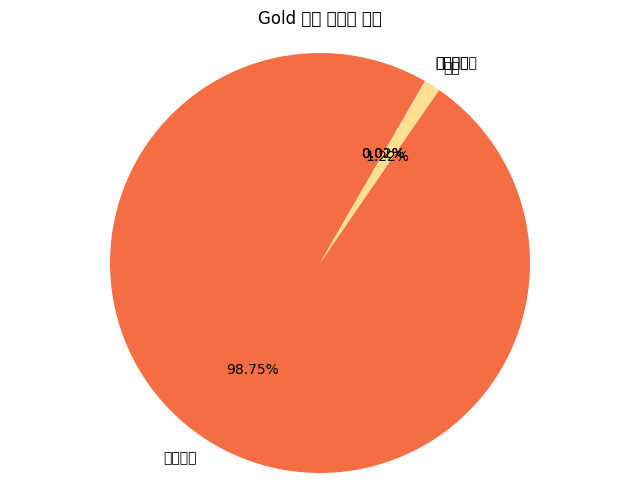

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# '연령대' 열의 값에 대한 개수 세기
member = normal['조합원상태'].value_counts()

# 색상 그라데이션 적용을 위한 색상 팔레트 선택
colors = sns.color_palette("RdYlBu", len(member))

# 파이 차트 그리기
plt.figure(figsize=(8, 6))
plt.pie(member, labels=member.index, colors=colors, autopct='%1.2f%%', startangle=60)
plt.title('Gold 회원 연령대 비율')
plt.axis('equal')  # 원형으로 조정
plt.show()

일반고객과 전체구매데이터 합침

In [9]:
merged_normal = pd.merge(normal, market, on=['회원번호', '조합원상태'])
merged_normal

,회원번호,조합원상태,시,주소,성별,연령,연령대,배송서비스신청여부,모바일알람여부,Gold_member,...,물품명,구매수량,구매금액,구매매장,구매시각,반품일자,구매월,구매일,구매시간대,반품소요기간
0,1000012800,정상회원,용인,수지구-풍덕천동,여,58.0,50대,미신청,.,normal,...,두부(1모:420g),2.0,7658,매장B,16:11:00,NaN,6,18,16,0
1,1000103744,정상회원,용인,처인구-고림동,여,34.0,30대,미신청,.,normal,...,닭고기볶음밥(300g),1.0,5743,매장C,13:27:00,NaN,10,17,13,0
2,1000103744,정상회원,용인,처인구-고림동,여,34.0,30대,미신청,.,normal,...,채소볶음밥(300g),1.0,4786,매장C,13:27:00,NaN,10,17,13,0
3,1000103744,정상회원,용인,처인구-고림동,여,34.0,30대,미신청,.,normal,...,하늘바다새우(60g),2.0,7083,매장C,13:27:00,NaN,10,17,13,0
4,1000103744,정상회원,용인,처인구-고림동,여,34.0,30대,미신청,.,normal,...,우리밀곡물와플(80g),1.0,3829,매장C,13:27:00,NaN,10,17,13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251526,99995712,정상회원,용인,수지구-상현동,여,66.0,60대,미신청,.,normal,...,아카시아꿀(460g),1.0,27759,매장B,13:29:00,NaN,10,13,13,0
251527,99995712,정상회원,용인,수지구-상현동,여,66.0,60대,미신청,.,normal,...,밤고구마(1kg),1.0,6700,매장B,17:45:00,NaN,10,21,17,0
251528,99995712,정상회원,용인,수지구-상현동,여,66.0,60대,미신청,.,normal,...,커스터드큐브빵(135g)/매장,1.0,5360,매장B,10:06:00,NaN,10,29,10,0
251529,99995712,정상회원,용인,수지구-상현동,여,66.0,60대,미신청,.,normal,...,중파(500g),1.0,4212,매장B,10:06:00,NaN,10,29,10,0


In [10]:
# 1. 고객별로 구매금액을 합산하여 총구매금액 계산
total_purchase_amount = merged_normal.groupby('회원번호')['구매금액'].sum()

# 2. 고객별로 구매한 물품들의 대분류, 중분류, 소분류를 기록
customer_purchase_categories = merged_normal.groupby('회원번호').agg({
    '물품대분류': lambda x: x.mode()[0],  # 가장 많이 구매한 대분류
    '물품중분류': lambda x: x.mode()[0],  # 가장 많이 구매한 중분류
    '물품소분류': lambda x: x.mode()[0]   # 가장 많이 구매한 소분류
})

# 3. 각 고객의 구매 내역을 요약하여 1인당 평균구매금액과 최고구매금액 계산
customer_purchase_summary = merged_normal.groupby('회원번호').agg({
    '구매금액': ['mean', 'max']  # 1인당 평균구매금액과 최고구매금액
})
customer_purchase_summary.columns = ['평균구매금액', '최고구매금액']

#고객 연령대
agegroup = merged_normal.groupby('회원번호')['연령대'].first()

# 고객별 총구매금액, 가장 많이 구매한 물품 대분류, 중분류, 소분류 정보를 합치기
normal_info = pd.concat([total_purchase_amount, customer_purchase_categories, customer_purchase_summary,agegroup], axis=1)

# 결과 출력
normal_info


,구매금액,물품대분류,물품중분류,물품소분류,평균구매금액,최고구매금액,연령대
회원번호,,,,,,,
18613824,21059,생활용품,생활용품,위생용품,21059.000000,21059,70대
18764160,-88827,생활용품,생활용품,위생용품,-8882.700000,21059,70대
18792000,33311,축산물,중량(정육),한우(중량),33311.000000,33311,80대 이상
18942336,560920,축산물,과일,기초화장품,17528.750000,70833,40대
18949760,2776,반찬,두부/유부,두부,2776.000000,2776,80대 이상
...,...,...,...,...,...,...,...
1644772352,85000,수산,냉동수산,기타냉동수산,42500.000000,49583,50대
1644957952,25079,간식,과자,가래떡,6269.750000,10529,40대
1670400000,13060734,간식,과자,스낵,9638.918081,357995,30대


Text(0.5, 1.0, 'normal 평균구매금액 분포')

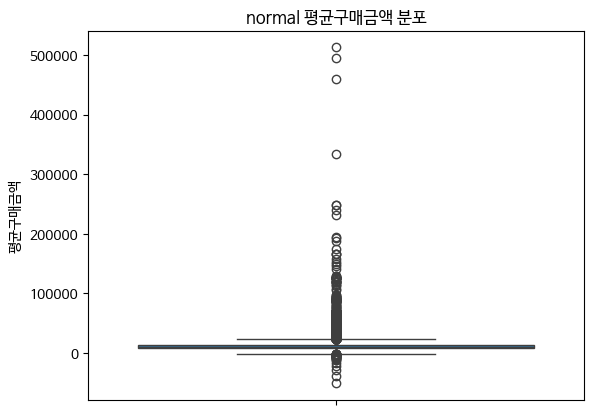

In [17]:
ax = sns.boxplot(normal_info['평균구매금액'])
ax.set_title('normal 평균구매금액 분포')

In [ ]:
normal_info['평균구매금액'].describe()

count     11350.000000
mean      12538.981707
std       14918.506117
min      -51306.000000
25%        7338.666667
50%        9977.971296
75%       13544.468750
max      513063.000000
Name: 평균구매금액, dtype: float64

In [ ]:
normal_info['물품대분류'].value_counts()

채소       3021
간식       2750
축산물      1654
반찬       1494
수산        547
생활용품      473
음료        424
양념/가루     403
건강        183
과실        181
주곡         86
잡곡         78
서류         36
기타         13
주류          7
Name: 물품대분류, dtype: int64

(array([1.1780e+03, 1.0053e+04, 7.8000e+01, 2.9000e+01, 4.0000e+00,
        4.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 3.0000e+00]),
 array([-51306. ,   5130.9,  61567.8, 118004.7, 174441.6, 230878.5,
        287315.4, 343752.3, 400189.2, 456626.1, 513063. ]),
 <BarContainer object of 10 artists>)

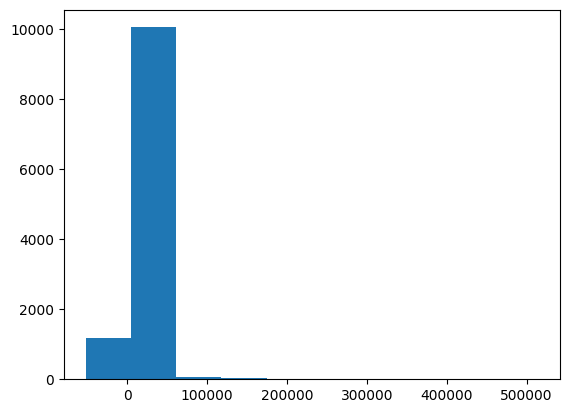

In [ ]:
plt.hist(normal_info['평균구매금액'])

# 시각화

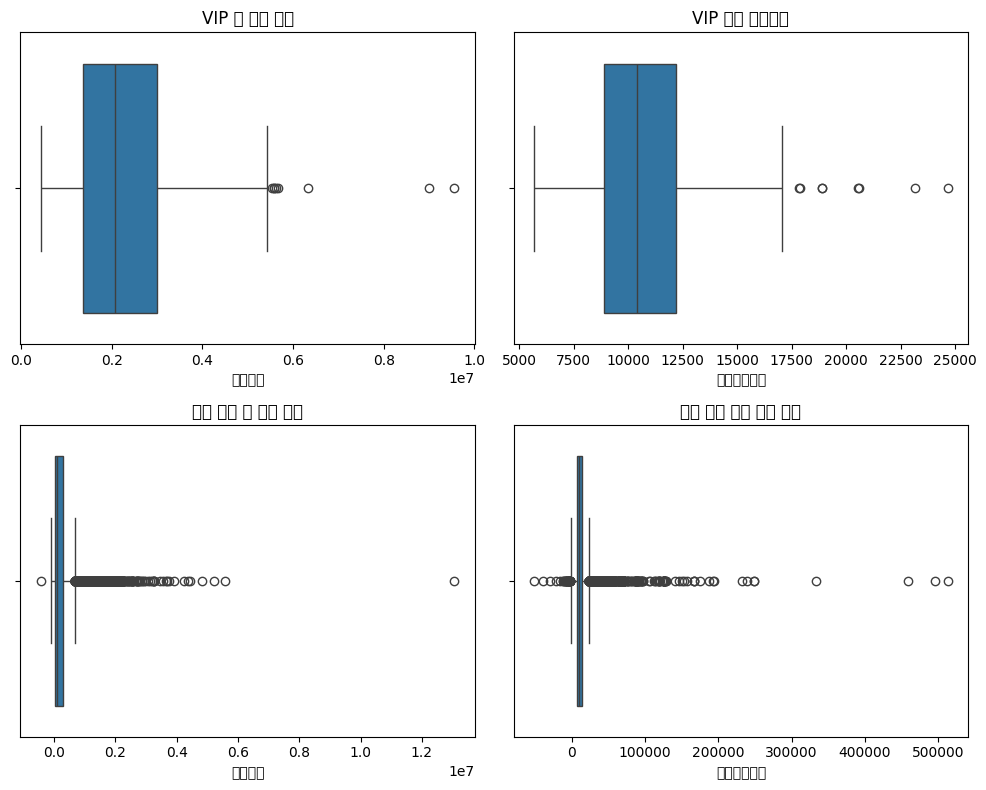

In [ ]:
# Figure 및 서브플롯 생성
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

# 각 서브플롯에 데이터 플롯
sns.boxplot(x=vip_info['구매금액'], ax=ax1)
ax1.set_title('VIP 총 구매 금액')

sns.boxplot(x=vip_info['평균구매금액'], ax=ax2)
ax2.set_title('VIP 평균 구매금액')

sns.boxplot(x=normal_info['구매금액'], ax=ax3)
ax3.set_title ('일반 고객 총 구매 금액')

sns.boxplot(x=normal_info['평균구매금액'], ax=ax4)
ax4.set_title('일반 고객 평균 구매 금액')

# 레이아웃 조정
plt.tight_layout()

# 그래프 표시
plt.show()


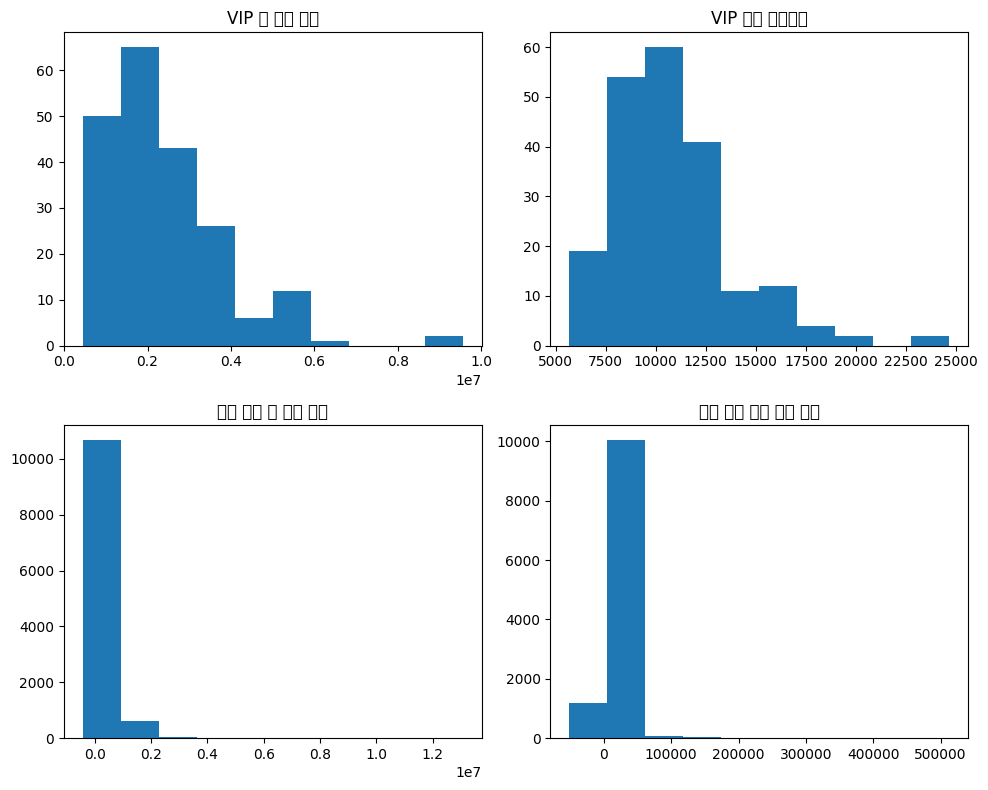

In [ ]:
# Figure 및 서브플롯 생성
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

# 각 서브플롯에 데이터 플롯
ax1.hist(vip_info['구매금액'])
ax1.set_title('VIP 총 구매 금액')

ax2.hist(vip_info['평균구매금액'])
ax2.set_title('VIP 평균 구매금액')

ax3.hist(normal_info['구매금액'])
ax3.set_title('일반 고객 총 구매 금액')

ax4.hist(normal_info['평균구매금액'])
ax4.set_title('일반 고객 평균 구매 금액')

# 레이아웃 조정
plt.tight_layout()

# 그래프 표시
plt.show()


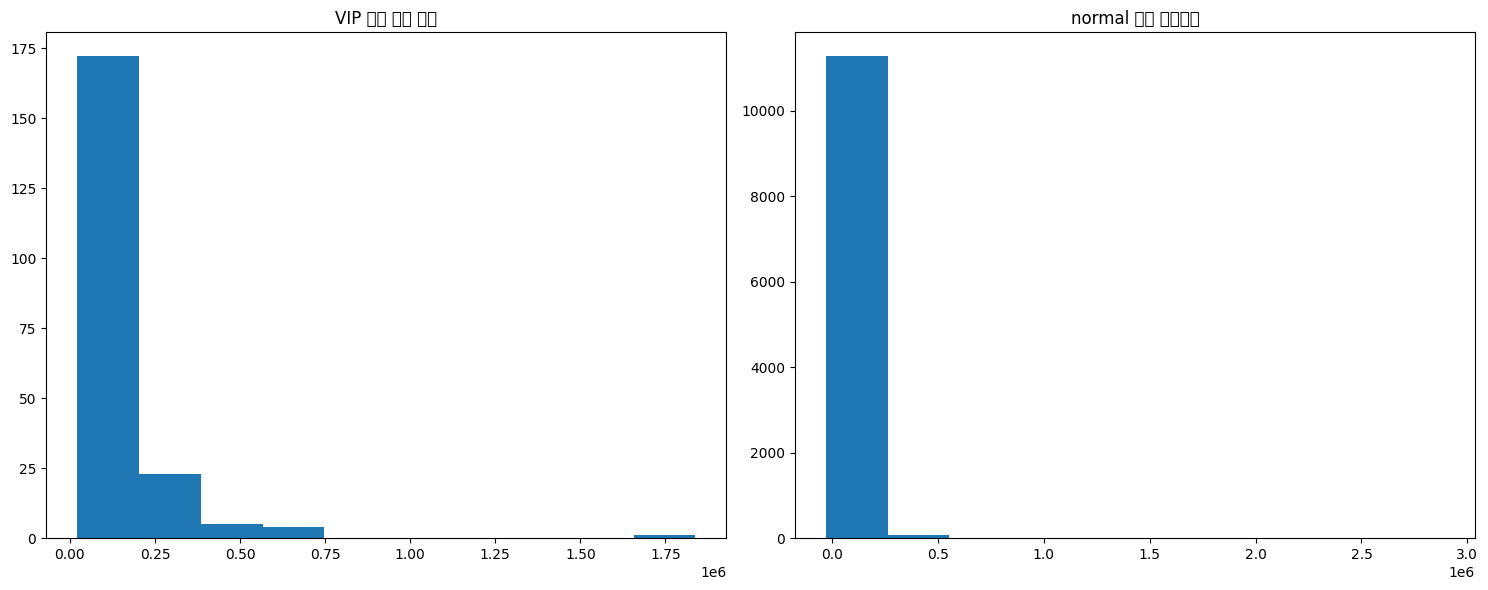

In [ ]:
# Figure 및 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 각 서브플롯에 데이터 플롯
ax1.hist(vip_info['최고구매금액'])
ax1.set_title('VIP 최고 구매 금액')

ax2.hist(normal_info['최고구매금액'])
ax2.set_title('normal 최고 구매금액')

# 레이아웃 조정
plt.tight_layout()

# 그래프 표시
plt.show()


# 기존 등급 많이 구매된 대분류

Text(0, 0.5, '구매 수')

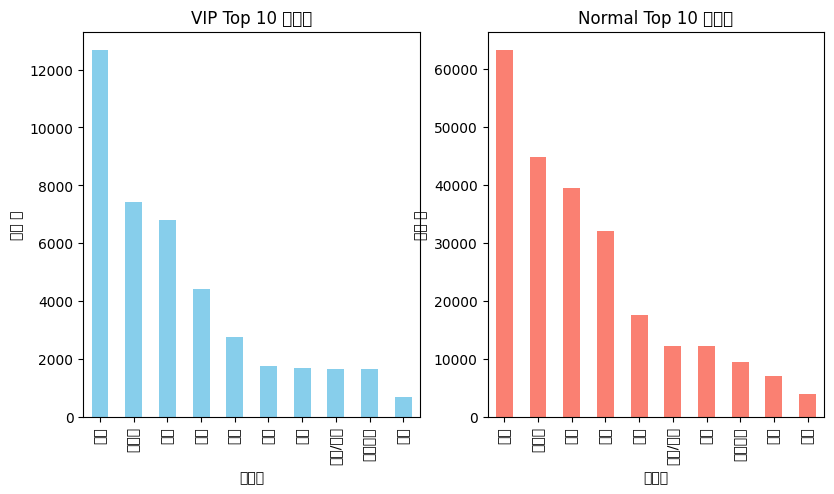

In [ ]:
import matplotlib.pyplot as plt

# 가장 많이 구매된 물품 대분류 추출
top_categories = merged_vip.groupby('물품대분류').size().nlargest(10)
topnormal_categories = merged_normal.groupby('물품대분류').size().nlargest(10)

# 그래프 그리기
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
top_categories.plot(kind='bar', color='skyblue')
plt.title('VIP Top 10 대분류')
plt.xlabel('대분류')
plt.ylabel('구매 수')

plt.subplot(1, 4, 2)
topnormal_categories.plot(kind='bar', color='salmon')
plt.title('Normal Top 10 대분류')
plt.xlabel('대분류')
plt.ylabel('구매 수')

In [ ]:
print("vip", top_categories)

vip 물품대분류
채소       12681
축산물       7409
간식        6813
반찬        4415
수산        2755
과실        1749
음료        1690
양념/가루     1656
생활용품      1629
서류         669
dtype: int64


In [ ]:
print("normal", topnormal_categories)

normal 물품대분류
채소       63284
축산물      44874
간식       39504
반찬       31985
수산       17581
양념/가루    12150
음료       12140
생활용품      9361
과실        7009
주곡        3953
dtype: int64
